In this notebook, we analyze the results from our adversarial 2048 simulations and compare the different algorithms used: minimax, expectimax, and Monte Carlo tree search.

In [47]:
from pandas import DataFrame
import seaborn as sns
from analysis.data_analysis import read_minimax_vs_random_data

In [48]:
df: DataFrame = read_minimax_vs_random_data()
print(df.columns)
df.describe()

Index(['score', 'turns_taken', 'execution_time', 'largest_tile', 'depth'], dtype='str')


,score,turns_taken,execution_time,largest_tile,depth
count,2700.000000,2700.000000,2700.000000,2700.000000,2700.000000
mean,4682.266667,675.882222,3.657091,394.690370,3.222222
std,2265.295177,247.949844,5.720288,188.492769,1.571639
min,560.000000,150.000000,0.016844,64.000000,1.000000
25%,3068.000000,502.000000,0.155752,256.000000,2.000000
50%,4660.000000,640.000000,0.627274,512.000000,3.000000
75%,6329.000000,854.000000,5.228233,512.000000,5.000000
max,16272.000000,1922.000000,48.353139,1024.000000,6.000000


What was the best search depth? Let's look at the graphs of how the mean scores improved as we increased the search depth

Text(0.5, 1.05, 'Distributions of Scores for Minimax against Random Player')

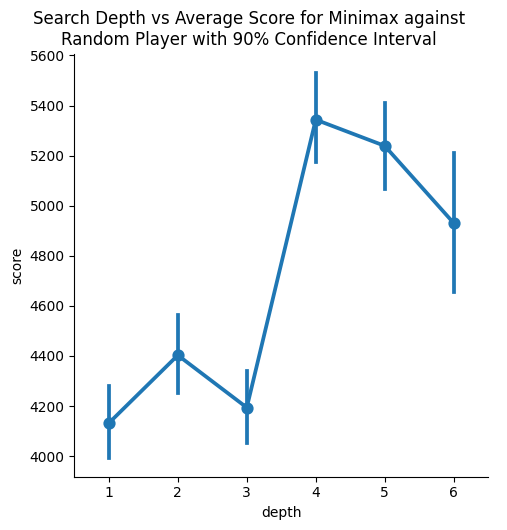

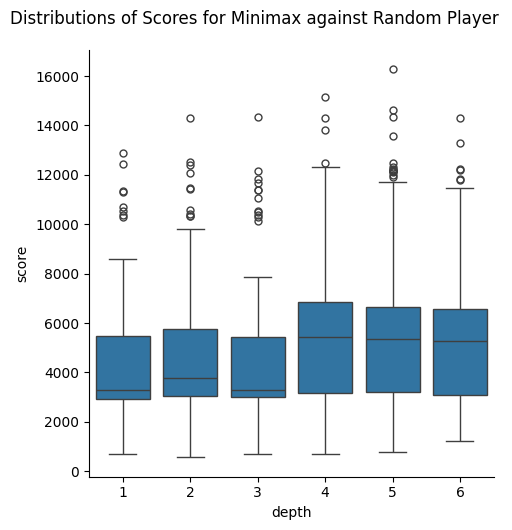

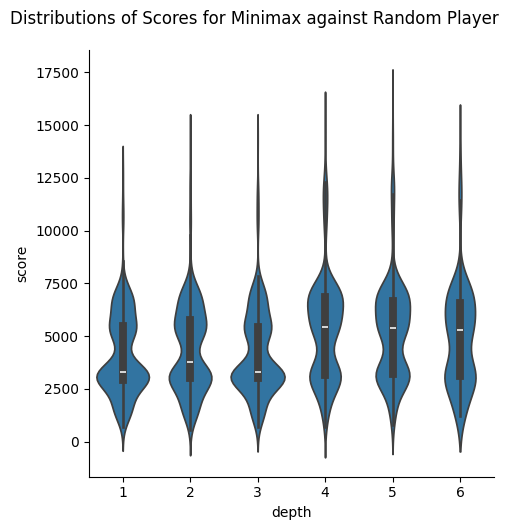

In [49]:
g1 = sns.catplot(data=df, x="depth", y="score", kind="point", errorbar=("ci",90))
g1.figure.suptitle(
    "Search Depth vs Average Score for Minimax against\nRandom Player with 90% Confidence Interval",
    y=1.05,
)

g2 = sns.catplot(data=df, x="depth", y="score", kind="box")
g2.figure.suptitle(
    "Distributions of Scores for Minimax against Random Player",
    y=1.05,
)

g3 = sns.catplot(data=df, x="depth", y="score", kind="violin")
g3.figure.suptitle(
    "Distributions of Scores for Minimax against Random Player",
    y=1.05,
)

For both the minimax being player one or two, it seems like there is a general upward trend as the search depth increases. For the simulated matches against adversaries other than a random adversary, we will be using a search depth of 5 for the sake of computation time.

Note: The high concentration around a score of 3000 in depths of 1-3 can be attributed to the "256 wall." Once the algorithms can pass this wall (like on depth 4 or greater), they are able to get much greater scores.

Text(0.5, 1.05, 'Distributions of Scores for Minimax against Random Player')

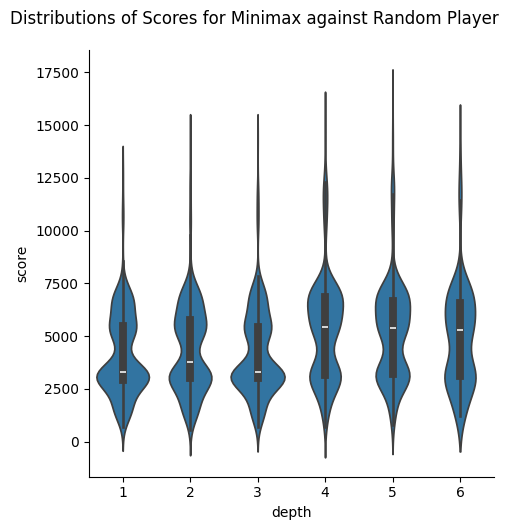

In [50]:
g1 = sns.catplot(data=df, x="depth", y="score", kind="violin")
g1.figure.suptitle(
    "Distributions of Scores for Minimax against Random Player",
    y=1.05,
)

In [51]:
df.groupby('depth')['execution_time'].mean()

depth
1     0.062311
2     0.198006
3     0.535994
4     4.337963
5     6.754041
6    19.649936
Name: execution_time, dtype: float64